# ICA05 — Working with geogrid, ungrib, and metgrid output in Python

This notebook is a streamlined introduction to reading and plotting `geo_em` and `met_em` files with xarray.

Julie.Lundquist@JHU.edu
2026 February (updated from 2023 version)

## Learning goals
By the end, you should be able to:
1. Open a `geo_em*` NetCDF file with `xarray` and make domain plots of terrain height and land/sea masks
2. Open `met_em` NetCDF files and assess meteorological variability
3. Compare sea-surface temperatures in varying `met_em`files



In [20]:
# --- Imports ---
import numpy as np
import pandas as pd
import xarray as xr
import re

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

from pathlib import Path
import glob

from matplotlib.axes import Axes # Makes the color bar easier to work with
from mpl_toolkits.axes_grid1 import make_axes_locatable # Color bar location
import matplotlib.ticker as mticker


from matplotlib.colors import ListedColormap, BoundaryNorm # Because I'm particular about color tables
from matplotlib.colors import Normalize # Because I'm particular about color tables
from matplotlib.colors import TwoSlopeNorm # to help normalize map factors so color table is centered on zero



print("Imports OK")

Imports OK


In [2]:
# Julie is particular about color tables for terrain....

class WaterLandNormalize(Normalize):
    def __init__(self, vmin=0, vmax=1000, water_frac=0.2, clip=False):
        self.water_frac = water_frac
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        value = np.asarray(value)

        # Initialize normalized array
        result = np.zeros_like(value, dtype=float)

        # Water (HGT == 0)
        water = value <= 0
        result[water] = 0.0

        # Land (HGT > 0)
        land = value > 0
        result[land] = self.water_frac + (
            (value[land] - 0) / (self.vmax - 0)
        ) * (1.0 - self.water_frac)

        return np.ma.masked_array(result)


## 1) Look at the geo_em file(s)

Set `DATA_DIR` to the folder containing your WRF output files (e.g., `wrfout_d01_YYYY-MM-DD_HH:MM:SS`).

If you're working on a shared system, copy the files you need into a directory you can read quickly (scratch or project space).


In [3]:
# --- Edit this path ---
DATA_DIR = Path(".")  # STUDENTS EDIT THIS Path("/path/to/your/wrfout/files")
DATA_DIR = Path("/scratch/alpine/jlundqui/NWP/")
# Find geo_em files
geo_em_file = 'geo_em.d01.nc' 



# Find candidate wrfout files
geo_em_files = sorted(DATA_DIR.glob("geo_em.d0*"))  # matches geo_em.d0*...
print(f"Found {len(geo_em_files)} geo_em file(s) in {DATA_DIR.resolve()}")

# If you have many files, you can pick one:
if len(geo_em_files) == 0:
    raise FileNotFoundError(
        "No geo_em_files found. Update DATA_DIR to the folder that contains geo_em_files."
    )

GEO_EM_FILE = geo_em_files[0]
print("Using:", GEO_EM_FILE.name)


Found 1 geo_em file(s) in /gpfs/alpine1/scratch/jlundqui/NWP
Using: geo_em.d01.nc


In [4]:
ds = xr.open_dataset(GEO_EM_FILE)

# Quick look 
ds


<xarray.Dataset>
Dimensions:     (Time: 1, south_north: 479, west_east: 479,
                 south_north_stag: 480, west_east_stag: 480, land_cat: 21,
                 soil_cat: 16, month: 12, num_urb_params: 132,
                 dust_erosion_dimension: 3)
Dimensions without coordinates: Time, south_north, west_east, south_north_stag,
                                west_east_stag, land_cat, soil_cat, month,
                                num_urb_params, dust_erosion_dimension
Data variables: (12/82)
    Times       (Time) |S19 ...
    XLAT_M      (Time, south_north, west_east) float32 ...
    XLONG_M     (Time, south_north, west_east) float32 ...
    XLAT_V      (Time, south_north_stag, west_east) float32 ...
    XLONG_V     (Time, south_north_stag, west_east) float32 ...
    XLAT_U      (Time, south_north, west_east_stag) float32 ...
    ...          ...
    OA4SS       (Time, south_north, west_east) float32 ...
    OL1SS       (Time, south_north, west_east) float32 ...
    OL2SS       (Time, south_north, west_east) float32 ...
    OL3SS       (Time, south_north, west_east) float32 ...
    OL4SS       (Time, south_north, west_east) float32 ...
    BATHYMETRY  (Time, south_north, west_east) float32 ...
Attributes: (12/56)
    TITLE:                           OUTPUT FROM GEOGRID V4.6.0
    SIMULATION_START_DATE:           0000-00-00_00:00:00
    WEST-EAST_GRID_DIMENSION:        480
    SOUTH-NORTH_GRID_DIMENSION:      480
    BOTTOM-TOP_GRID_DIMENSION:       0
    WEST-EAST_PATCH_START_UNSTAG:    1
    ...                              ...
    FLAG_IMPERV:                     1
    FLAG_CANFRA:                     1
    FLAG_EROD:                       1
    FLAG_CLAYFRAC:                   1
    FLAG_SANDFRAC:                   1
    FLAG_BATHYMETRY:                 1

In [30]:
# Inspect dimensions and variables

print("Dimensions:")
for k, v in ds.dims.items():
    print(f"  {k}: {v}")

# Show a short list of variables (first ~30)
vars_list = list(ds.data_vars)
print("\nData variables (first 30):")
print(vars_list[:30])

Dimensions:
  Time: 1
  south_north: 479
  west_east: 479
  south_north_stag: 480
  west_east_stag: 480
  land_cat: 21
  soil_cat: 16
  month: 12
  num_urb_params: 132
  dust_erosion_dimension: 3

Data variables (first 30):
['Times', 'XLAT_M', 'XLONG_M', 'XLAT_V', 'XLONG_V', 'XLAT_U', 'XLONG_U', 'CLAT', 'CLONG', 'MAPFAC_M', 'MAPFAC_V', 'MAPFAC_U', 'MAPFAC_MX', 'MAPFAC_VX', 'MAPFAC_UX', 'MAPFAC_MY', 'MAPFAC_VY', 'MAPFAC_UY', 'E', 'F', 'SINALPHA', 'COSALPHA', 'LANDMASK', 'XLAT_C', 'XLONG_C', 'SINALPHA_U', 'COSALPHA_U', 'SINALPHA_V', 'COSALPHA_V', 'LANDUSEF']


Map bounds [lon_min, lon_max, lat_min, lat_max]: [-91.32171630859375, -48.678314208984375, 25.41959571838379, 53.107601165771484]
[OK] Saved figure → HGT.png


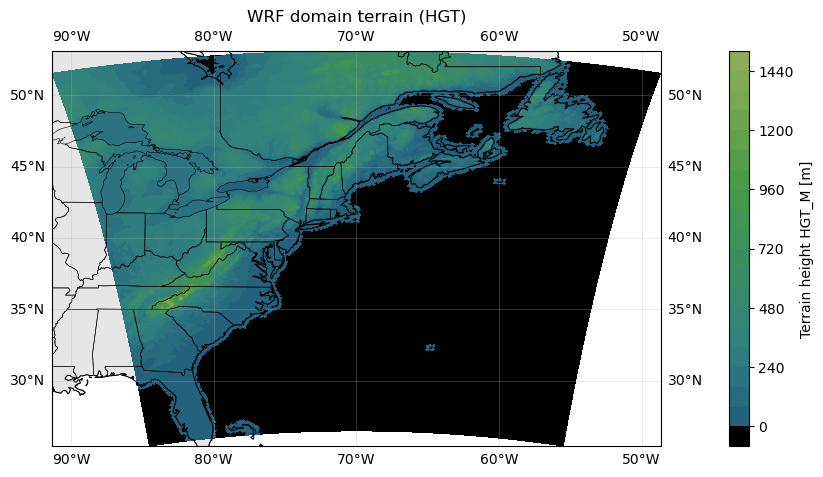

In [6]:

# 2D lat/lon for mapping
lat = ds["XLAT_M"].isel(Time=0)
lon = ds["XLONG_M"].isel(Time=0)

# Terrain height HGT (meters)
hgt = ds["HGT_M"].isel(Time=0)

bounds = [float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max())]
print("Map bounds [lon_min, lon_max, lat_min, lat_max]:", bounds)

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(9, 4.8))
ax = plt.axes(projection=proj)


ax.set_extent(bounds, crs=proj)
ax.add_feature(cfeature.LAND, facecolor="0.9")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.STATES, linewidth=0.4)
ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)

norm = WaterLandNormalize(vmin=0, vmax=3000, water_frac=0.2)

cf = ax.contourf(
    lon, lat, hgt,
    levels=20,
    cmap="gist_earth",
    norm=norm,
    transform=proj,
)


divider = make_axes_locatable(ax)

cbar = plt.colorbar(cf, ax=ax)
cbar.set_label("Terrain height HGT_M [m]")
# cbar.set_ticks([0, 500, 1000, 1500, 2000, 2500, 3000])


ax.set_title("WRF domain terrain (HGT)")
fig.tight_layout()

save='HGT.png'
fig.savefig(save, dpi=200)
print(f"[OK] Saved figure → {save}")


plt.show()



In [7]:
landmask = ds["LANDMASK"].isel(Time=0) 
landmask

<xarray.DataArray 'LANDMASK' (south_north: 479, west_east: 479)>
[229441 values with dtype=float32]
Dimensions without coordinates: south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    units:        none
    description:  Landmask : 1=land, 0=water
    stagger:      M
    sr_x:         1
    sr_y:         1

[OK] Saved figure → LANDMASK.png


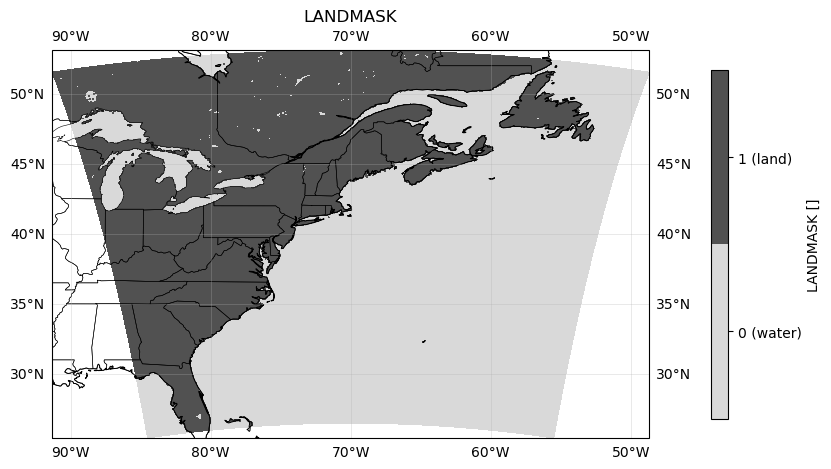

In [26]:
## Assess the land sea mask as this is generally useful to understand your data


# --- pick the mask variable name used in your file ---
landmask = ds["LANDMASK"].isel(Time=0)   # 0=water, 1=land (typical WRF)

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(9, 4.8))
ax = plt.axes(projection=proj)
ax.set_extent(bounds, crs=proj)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.STATES, linewidth=0.4)
ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)

divider = make_axes_locatable(ax)


# Levels that separate 0 and 1 cleanly:
levels = [-0.5, 0.5, 1.5]

cf = ax.contourf(
    lon, lat, landmask,
    levels=levels,
    transform=proj,
    cmap="Greys",   # or "Blues", "binary", etc.
    extend="neither"
)

# # Optional: draw the land/sea boundary (where mask changes)
# cs = ax.contour(
#     lon, lat, landmask,
#     levels=[0.5],
#     colors="k",
#     linewidths=0.8,
#     transform=proj
# )

cbar = plt.colorbar(cf, ax=ax, pad=0.02, shrink=0.9)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["0 (water)", "1 (land)"])
cbar.set_label("LANDMASK []")

ax.set_title("LANDMASK")

plt.tight_layout()
save = "LANDMASK.png"
fig.savefig(save, dpi=200)
print(f"[OK] Saved figure → {save}")
plt.show()


[OK] Saved figure → LANDMASK.png


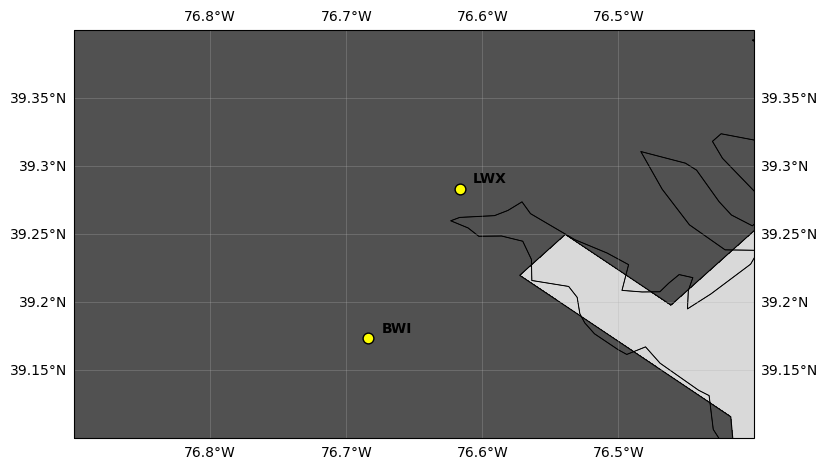

In [17]:
# zoom in on Baltimore City - is the inner harbor represented at all?
## Assess the land sea mask

landmask = ds["LANDMASK"].isel(Time=0)   # 0=water, 1=land (typical WRF)

bounds = [-76.9, -76.4, 39.1, 39.4] # subset to zoom in on Inner Harbor

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(9, 4.8))
ax = plt.axes(projection=proj)
ax.set_extent(bounds, crs=proj)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.STATES, linewidth=0.4)
ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)

divider = make_axes_locatable(ax)


# Levels that separate 0 and 1 cleanly:
levels = [-0.5, 0.5, 1.5]

cf = ax.contourf(
    lon, lat, landmask,
    levels=levels,
    transform=proj,
    cmap="Greys",   # or "Blues", "binary", etc.
    extend="neither"
)

# Optional: draw the land/sea boundary (where mask changes)
cs = ax.contour(
    lon, lat, landmask,
    levels=[0.5],
    colors="k",
    linewidths=0.8,
    transform=proj
)

# LWX location
lwx_lat = 39.28333
lwx_lon = -76.61667

# Plot the point
ax.scatter(
    lwx_lon, lwx_lat,
    color="yellow",
    edgecolor="k",
    s=60,
    zorder=5,
    transform=proj
)

# Add the label
ax.text(
    lwx_lon + 0.01, lwx_lat + 0.005,  # small offset so text doesn't overlap dot
    "LWX",
    fontsize=10,
    fontweight="bold",
    color="black",
    transform=proj,
    zorder=6
)
###### 
# BWI location
bwi_lat = 39.17329
bwi_lon = -76.68408

# Plot the point
ax.scatter(
    bwi_lon, bwi_lat,
    color="yellow",
    edgecolor="k",
    s=60,
    zorder=5,
    transform=proj
)

# Add the label
ax.text(
    bwi_lon + 0.01, bwi_lat + 0.005,  # small offset so text doesn't overlap dot
    "BWI",
    fontsize=10,
    fontweight="bold",
    color="black",
    transform=proj,
    zorder=6
)


# cbar = plt.colorbar(cf, ax=ax, pad=0.02, shrink=0.9)
# cbar.set_ticks([0, 1])
# cbar.set_ticklabels(["0 (water)", "1 (land)"])
# cbar.set_label("LANDMASK []")

# ax.set_title("LANDMASK")

plt.tight_layout()
save = "LANDMASK.png"
fig.savefig(save, dpi=200)
print(f"[OK] Saved figure → {save}")
plt.show()


## 2) Compare two met_em files

Here we compare SKINTEMP from two different input files. Note that we use SKINTEMP rather than SST.


Found 2 met_em file(s) in /gpfs/alpine1/scratch/jlundqui/NWP/compare_d02
[PosixPath('/scratch/alpine/jlundqui/NWP/compare_d02/met_em.d02.2020-04-05_00:00:00.nc'), PosixPath('/scratch/alpine/jlundqui/NWP/compare_d02/met_em_deprecated.d02.2020-04-05_00:00:00.nc')]
File 1: /scratch/alpine/jlundqui/NWP/compare_d02/met_em.d02.2020-04-05_00:00:00.nc
File 2: /scratch/alpine/jlundqui/NWP/compare_d02/met_em_deprecated.d02.2020-04-05_00:00:00.nc
SKINTEMP range: 275.5960693359375 to 297.7349548339844
[OK] Saved figure → SKINTEMP_side_by_side.png


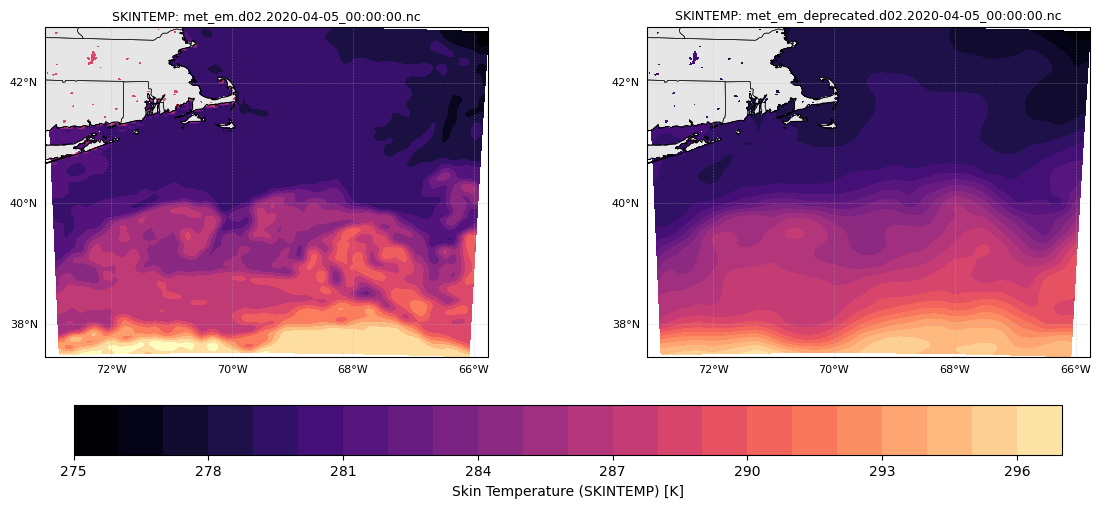

In [26]:
# ------------------------------------------------------------
# 1. Select input files
# ------------------------------------------------------------


DATA_DIR = Path("/scratch/alpine/jlundqui/NWP/compare_d02")


met_em_files = sorted(DATA_DIR.glob("met_em*d02.2020-04-05_00:00:00.nc"))  # matches 2020-04-05_00:00:00.nc...
# met_em_files = sorted(DATA_DIR.glob("ostia*"))  # matches wrfout_d01_...
print(f"Found {len(met_em_files)} met_em file(s) in {DATA_DIR.resolve()}")

print(met_em_files)
# If you have many files, you can pick one:
if len(met_em_files) == 0:
    raise FileNotFoundError(
        "No met_em_files found. Update DATA_DIR to the folder that contains met_em_files."
    )

file1 = met_em_files[0]
file2 = met_em_files[1]

print("File 1:", file1)
print("File 2:", file2)

# Open both datasets
ds1 = xr.open_dataset(file1)
ds2 = xr.open_dataset(file2)

# ------------------------------------------------------------
# 2. Extract lat/lon (same grid assumed)
# ------------------------------------------------------------
lat = ds1["XLAT_M"].isel(Time=0)
lon = ds1["XLONG_M"].isel(Time=0)
landmask = ds1["LANDMASK"].isel(Time=0)

bounds = [float(lon.min()), float(lon.max()),
          float(lat.min()), float(lat.max())]

# ------------------------------------------------------------
# 3. Extract SKINTEMP fields
# ------------------------------------------------------------
skin1 = ds1["SKINTEMP"].isel(Time=0)
skin2 = ds2["SKINTEMP"].isel(Time=0)

# Shared color limits for comparison
vmin = float(min(skin1.min(), skin2.min() ))
vmax = float(max(skin1.max(), skin2.max() ))

print("SKINTEMP range:", vmin, "to", vmax)

# ------------------------------------------------------------
# 4. Plot side-by-side
# ------------------------------------------------------------
proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

titles = [
    f"SKINTEMP: {file1.name}",
    f"SKINTEMP: {file2.name}",
#     f"SKINTEMP: {file3.name}"
]

for ax, skin, title in zip(axes, [skin1, skin2], titles):

    skin_water = skin.where(landmask == 0)
    
    ax.set_extent(bounds, crs=proj)

    ax.add_feature(cfeature.LAND, facecolor="0.9")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.STATES, linewidth=0.4)

#     ax.gridlines(draw_labels=False, linewidth=0.4, alpha=0.5)

    gl = ax.gridlines(
        crs=proj,
        draw_labels=True,
        linewidth=0.4,
        alpha=0.5,
        linestyle="--"
    )

    # Only label left and bottom axes (prevents clutter)
    gl.top_labels = False
    gl.right_labels = False

    # Control tick locations (optional but looks much better)
    gl.xlocator = mticker.FixedLocator(
        np.arange(-180, 181, 2)   # change spacing as needed
    )
    gl.ylocator = mticker.FixedLocator(
        np.arange(-90, 91, 2)
    )

    # Format tick labels nicely
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    # Font size
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}


    cf = ax.contourf(
        lon, lat, skin_water,
        levels=20,
        cmap="magma", #"coolwarm",
        vmin=vmin, vmax=vmax,
        transform=proj
    )
    
    ax.set_title(title, fontsize=9)

# ------------------------------------------------------------
# 5. Shared colorbar
# ------------------------------------------------------------
cbar = fig.colorbar(cf, ax=axes, orientation="horizontal", pad=0.08)
cbar.set_label("Skin Temperature (SKINTEMP) [K]")

# ------------------------------------------------------------
# 6. Save figure
# ------------------------------------------------------------
save = "SKINTEMP_side_by_side.png"
fig.savefig(save, dpi=200)
print(f"[OK] Saved figure → {save}")

plt.show()


Found 2 met_em file(s) in /gpfs/alpine1/scratch/jlundqui/NWP/compare_d02
[PosixPath('/scratch/alpine/jlundqui/NWP/compare_d02/met_em.d02.2020-04-04_12:00:00.nc'), PosixPath('/scratch/alpine/jlundqui/NWP/compare_d02/met_em_deprecated.d02.2020-04-04_12:00:00.nc')]
File 1: /scratch/alpine/jlundqui/NWP/compare_d02/met_em.d02.2020-04-04_12:00:00.nc
File 2: /scratch/alpine/jlundqui/NWP/compare_d02/met_em_deprecated.d02.2020-04-04_12:00:00.nc
ΔSKINTEMP range: -13.623 to 5.930 K (plotting ±13.7 K)
[OK] Saved figure → SKINTEMP_difference_map.png


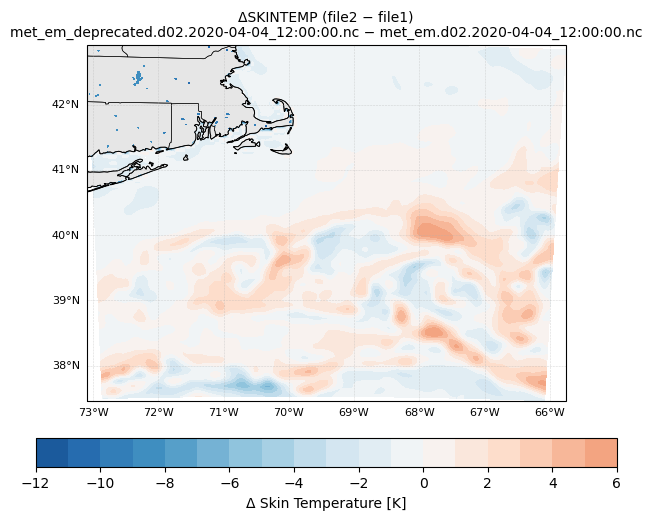

In [27]:
# Plot the difference fields

# ------------------------------------------------------------
# 1. Select two input files (original + deprecated)
# ------------------------------------------------------------
DATA_DIR = Path("/scratch/alpine/jlundqui/NWP/compare_d02")

met_em_files = sorted(DATA_DIR.glob("met_em*d02.2020-04-04_12:00:00.nc"))
print(f"Found {len(met_em_files)} met_em file(s) in {DATA_DIR.resolve()}")
print(met_em_files)

if len(met_em_files) < 2:
    raise FileNotFoundError("Need at least two files (original + deprecated).")

file1 = met_em_files[0]
file2 = met_em_files[1]

print("File 1:", file1)
print("File 2:", file2)

ds1 = xr.open_dataset(file1)
ds2 = xr.open_dataset(file2)

# ------------------------------------------------------------
# 2. Extract lat/lon
# ------------------------------------------------------------
lat = ds1["XLAT_M"].isel(Time=0)
lon = ds1["XLONG_M"].isel(Time=0)
landmask = ds1["LANDMASK"].isel(Time=0)

bounds = [float(lon.min()), float(lon.max()),
          float(lat.min()), float(lat.max())]

# ------------------------------------------------------------
# 3. Extract SKINTEMP + compute difference
# ------------------------------------------------------------
skin1 = ds1["SKINTEMP"].isel(Time=0)
skin2 = ds2["SKINTEMP"].isel(Time=0)

diff = skin2 - skin1  # <-- choose sign convention here
diff_water = diff.where(landmask == 0)

# Symmetric color limits around 0
absmax = float(np.nanmax(np.abs(diff.values)))
# Optional: round to something nice
absmax = np.ceil(absmax * 10) / 10.0  # nearest 0.1 K

norm = TwoSlopeNorm(vmin=-absmax, vcenter=0.0, vmax=absmax)

print(f"ΔSKINTEMP range: {float(diff.min()):.3f} to {float(diff.max()):.3f} K (plotting ±{absmax:.1f} K)")

# ------------------------------------------------------------
# 4. Plot difference map
# ------------------------------------------------------------
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(7.5, 6))
ax = plt.axes(projection=proj)

ax.set_extent(bounds, crs=proj)
ax.add_feature(cfeature.LAND, facecolor="0.9")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.STATES, linewidth=0.4)

gl = ax.gridlines(
    crs=proj,
    draw_labels=True,
    linewidth=0.4,
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}

# If you want tighter ticks, replace these with MultipleLocator
# gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 2))
# gl.ylocator = mticker.FixedLocator(np.arange(-90, 91, 2))

cf = ax.contourf(
    lon, lat, diff_water,
    levels=21,
    cmap="RdBu_r",          # diverging
    norm=norm,
    transform=proj
)

ax.set_title(f"ΔSKINTEMP (file2 − file1)\n{file2.name} − {file1.name}", fontsize=10)

cbar = plt.colorbar(cf, ax=ax, orientation="horizontal", pad=0.08)
cbar.set_label("Δ Skin Temperature [K]")

# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------
save = "SKINTEMP_difference_map.png"
fig.savefig(save, dpi=200)
print(f"[OK] Saved figure → {save}")

plt.show()



Found 2 met_em file(s) in /gpfs/alpine1/scratch/jlundqui/NWP/compare_d02
[PosixPath('/scratch/alpine/jlundqui/NWP/compare_d02/met_em.d02.2020-04-05_00:00:00.nc'), PosixPath('/scratch/alpine/jlundqui/NWP/compare_d02/met_em_deprecated.d02.2020-04-05_00:00:00.nc')]
File 1 (OSTIA): /scratch/alpine/jlundqui/NWP/compare_d02/met_em.d02.2020-04-05_00:00:00.nc
File 2 (deprecated): /scratch/alpine/jlundqui/NWP/compare_d02/met_em_deprecated.d02.2020-04-05_00:00:00.nc
SKINTEMP (water-only) range: 275.5960693359375 to 297.7349548339844
ΔSKINTEMP (water-only) max abs: 12.20 K
[OK] Saved figure → SKINTEMP_three_panel_teaching.png


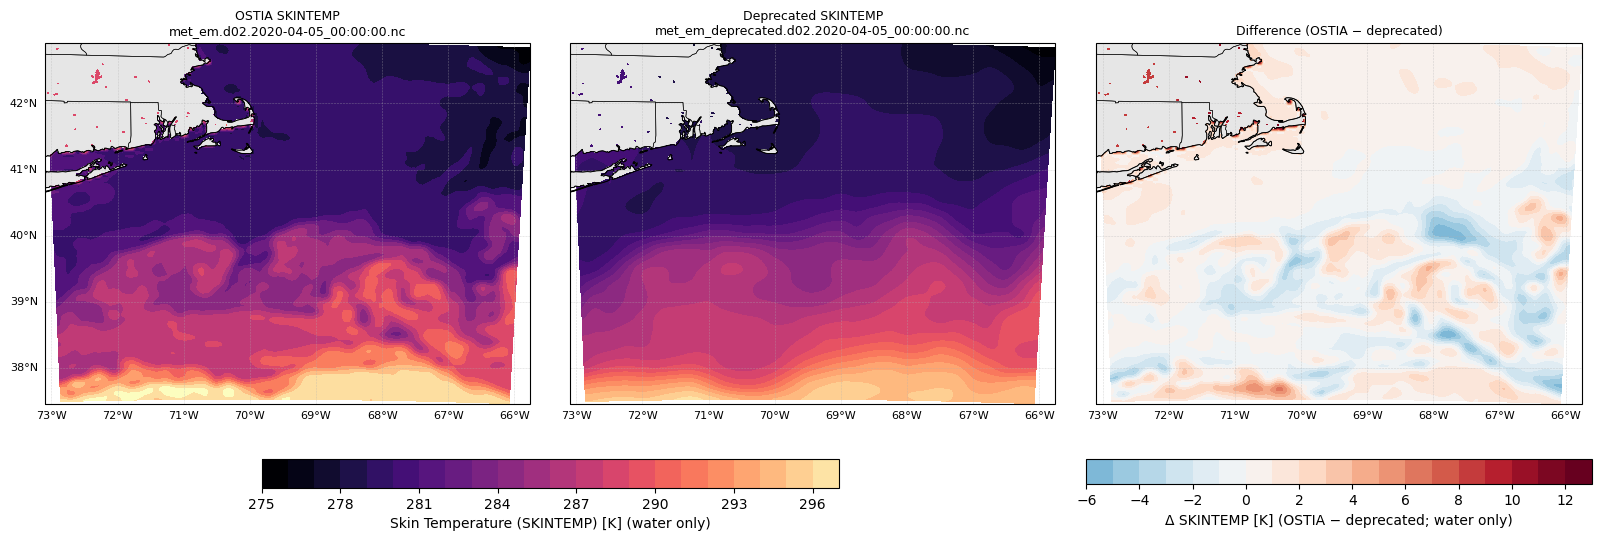

In [29]:
# ------------------------------------------------------------
# 1. Select two input files
# ------------------------------------------------------------
DATA_DIR = Path("/scratch/alpine/jlundqui/NWP/compare_d02")
met_em_files = sorted(DATA_DIR.glob("met_em*d02.2020-04-05_00:00:00.nc"))

print(f"Found {len(met_em_files)} met_em file(s) in {DATA_DIR.resolve()}")
print(met_em_files)

if len(met_em_files) < 2:
    raise FileNotFoundError("Need at least two files (OSTIA + deprecated).")

file1 = met_em_files[0]  # OSTIA-overwritten (assuming)
file2 = met_em_files[1]  # deprecated (assuming)

print("File 1 (OSTIA):", file1)
print("File 2 (deprecated):", file2)

ds1 = xr.open_dataset(file1)
ds2 = xr.open_dataset(file2)

# ------------------------------------------------------------
# 2. Extract lat/lon + landmask
# ------------------------------------------------------------
proj = ccrs.PlateCarree()

lat = ds1["XLAT_M"].isel(Time=0)
lon = ds1["XLONG_M"].isel(Time=0)
landmask = ds1["LANDMASK"].isel(Time=0)  # 1=land, 0=water

bounds = [float(lon.min()), float(lon.max()),
          float(lat.min()), float(lat.max())]

# ------------------------------------------------------------
# 3. Extract SKINTEMP, mask land, and compute difference
# ------------------------------------------------------------
skin1 = ds1["SKINTEMP"].isel(Time=0)
skin2 = ds2["SKINTEMP"].isel(Time=0)

# Mask land everywhere (keep only water points)
skin1_w = skin1.where(landmask == 0)
skin2_w = skin2.where(landmask == 0)

diff_w = (skin1 - skin2).where(landmask == 0)  # OSTIA - deprecated, ocean only

# Shared limits for absolute SKINTEMP panels (use ONLY water points)
vmin = float(np.nanmin([skin1_w.min().values, skin2_w.min().values]))
vmax = float(np.nanmax([skin1_w.max().values, skin2_w.max().values]))
print("SKINTEMP (water-only) range:", vmin, "to", vmax)

# Symmetric limits for difference
absmax = float(np.nanmax(np.abs(diff_w.values)))
absmax = np.ceil(absmax * 10) / 10.0  # round to 0.1 K for nicer label
diff_norm = TwoSlopeNorm(vmin=-absmax, vcenter=0.0, vmax=absmax)
print(f"ΔSKINTEMP (water-only) max abs: {absmax:.2f} K")

# ------------------------------------------------------------
# 4. Plot: 3 panels
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5.2),
    subplot_kw={"projection": proj},
    constrained_layout=True
)

panels = [
    (axes[0], skin1_w, f"OSTIA SKINTEMP\n{file1.name}", "magma", None, (vmin, vmax)),
    (axes[1], skin2_w, f"Deprecated SKINTEMP\n{file2.name}", "magma", None, (vmin, vmax)),
    (axes[2], diff_w,  "Difference (OSTIA − deprecated)", "RdBu_r", diff_norm, None),
]

for i, (ax, field, title, cmap, norm, vlim) in enumerate(panels):
    ax.set_extent(bounds, crs=proj)

    # Background + outlines
    ax.add_feature(cfeature.LAND, facecolor="0.9", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=3)
    ax.add_feature(cfeature.STATES, linewidth=0.4, zorder=3)

    # Gridlines/labels
    gl = ax.gridlines(
        crs=proj,
        draw_labels=True,
        linewidth=0.4,
        alpha=0.5,
        linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False
    if i > 0:  # avoid repeated latitude labels
        gl.left_labels = False

    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

    # Optional: tighter tick spacing for your regional domain (recommended)
    # Uncomment and adjust spacing (e.g., 1 degree)
    # gl.xlocator = mticker.MultipleLocator(1)
    # gl.ylocator = mticker.MultipleLocator(1)

    # Plot field
    if vlim is not None:
        cf = ax.contourf(
            lon, lat, field,
            levels=20,
            cmap=cmap,
            vmin=vlim[0], vmax=vlim[1],
            transform=proj
        )
    else:
        cf = ax.contourf(
            lon, lat, field,
            levels=21,
            cmap=cmap,
            norm=norm,
            transform=proj
        )

    ax.set_title(title, fontsize=9)

    # Store handles for colorbars
    if i == 1:
        cf_abs = cf          # for shared SKINTEMP colorbar (panels 1–2)
    if i == 2:
        cf_diff = cf         # for difference colorbar

# ------------------------------------------------------------
# 5. Colorbars
# ------------------------------------------------------------
# Shared colorbar for panels 1–2
cbar1 = fig.colorbar(cf_abs, ax=axes[:2], orientation="horizontal", pad=0.10, fraction=0.08)
cbar1.set_label("Skin Temperature (SKINTEMP) [K] (water only)")

# Separate colorbar for difference panel
cbar2 = fig.colorbar(cf_diff, ax=axes[2], orientation="horizontal", pad=0.10, fraction=0.08)
cbar2.set_label("Δ SKINTEMP [K] (OSTIA − deprecated; water only)")

# ------------------------------------------------------------
# 6. Save
# ------------------------------------------------------------
save = "SKINTEMP_three_panel_teaching.png"
fig.savefig(save, dpi=200)
print(f"[OK] Saved figure → {save}")

plt.show()


## 3) Evaluate a time series of SKINTEMP at one location

Here we compare SKINTEMP from two different input files. Note that we use SKINTEMP rather than SST.


In [ ]:
DATA_DIR = Path("/scratch/alpine/jlundqui/NWP/compare_d02")

desired_lat = 39.0
desired_lon = -70.0

start = pd.Timestamp("2020-04-04 00:00:00")
end   = pd.Timestamp("2020-04-06 00:00:00")  
# -----------------------------
# Helpers
# -----------------------------
def parse_time_from_filename(p: Path) -> pd.Timestamp:
    """
    Extract 'YYYY-MM-DD_HH:MM:SS' from met_em filename and return pandas Timestamp.
    """
    m = re.search(r"(\d{4}-\d{2}-\d{2}_\d{2}:\d{2}:\d{2})", p.name)
    if not m:
        raise ValueError(f"Could not parse time from filename: {p.name}")
    return pd.to_datetime(m.group(1), format="%Y-%m-%d_%H:%M:%S")

def nearest_ij_from_latlon(ds, lat0, lon0):
    """
    Return (j,i) indices of nearest grid point to (lat0, lon0) using XLAT_M/XLONG_M.
    Works for curvilinear grids.
    """
    lat = ds["XLAT_M"].isel(Time=0).values
    lon = ds["XLONG_M"].isel(Time=0).values

    # handle possible 0..360 longitudes
    if lon.max() > 180 and lon0 < 0:
        lon0_use = lon0 % 360.0
    else:
        lon0_use = lon0

    dist2 = (lat - lat0)**2 + (lon - lon0_use)**2
    j, i = np.unravel_index(np.nanargmin(dist2), dist2.shape)
    return int(j), int(i)

def extract_timeseries(file_list, lat0, lon0, label=""):
    """
    Given a list of met_em files, return a DataFrame with columns:
      time, skintemp
    using nearest gridpoint to (lat0, lon0) determined from the first file.
    """
    if len(file_list) == 0:
        raise ValueError(f"No files provided for {label}")

    # Open first file to locate nearest grid point
    ds0 = xr.open_dataset(file_list[0])
    j, i = nearest_ij_from_latlon(ds0, lat0, lon0)

    # also store actual lat/lon of chosen point for sanity
    actual_lat = float(ds0["XLAT_M"].isel(Time=0, south_north=j, west_east=i).values)
    actual_lon = float(ds0["XLONG_M"].isel(Time=0, south_north=j, west_east=i).values)
    ds0.close()

    times = []
    vals = []

    for f in file_list:
        t = parse_time_from_filename(f)
        ds = xr.open_dataset(f)
        v = float(ds["SKINTEMP"].isel(Time=0, south_north=j, west_east=i).values)
        ds.close()

        times.append(t)
        vals.append(v)

    out = pd.DataFrame({"time": times, "skintemp": vals}).sort_values("time")
    out.attrs["j"] = j
    out.attrs["i"] = i
    out.attrs["actual_lat"] = actual_lat
    out.attrs["actual_lon"] = actual_lon
    return out

# -----------------------------
# 1) Collect files for both cases
# -----------------------------
orig_files = sorted(DATA_DIR.glob("met_em.d02.2020-04-*.nc"))
depr_files = sorted(DATA_DIR.glob("met_em_deprecated.d02.2020-04-*.nc"))

# Filter to your window (optional but recommended)
orig_files = [f for f in orig_files if start <= parse_time_from_filename(f) <= end]
depr_files = [f for f in depr_files if start <= parse_time_from_filename(f) <= end]

print(f"Found {len(orig_files)} original files")
print(f"Found {len(depr_files)} deprecated files")

# -----------------------------
# 2) Extract time series
# -----------------------------
df_orig = extract_timeseries(orig_files, desired_lat, desired_lon, label="original")
df_depr = extract_timeseries(depr_files, desired_lat, desired_lon, label="deprecated")

print("Nearest gridpoint used (from original):",
      f"j={df_orig.attrs['j']}, i={df_orig.attrs['i']}, "
      f"lat={df_orig.attrs['actual_lat']:.4f}, lon={df_orig.attrs['actual_lon']:.4f}")

# Sanity check: same timestamps?
# (If they differ, the plot still works; you’ll just see different sampling.)
# -----------------------------
# 3) Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df_orig["time"], df_orig["skintemp"], marker="o", label="OSTIA")
ax.plot(df_depr["time"], df_depr["skintemp"], marker="o", label="ERA5")

ax.set_ylabel("SKINTEMP [K]")
ax.set_xlabel("Time")
ax.set_title(f"SKINTEMP at nearest grid point to ({desired_lat}, {desired_lon})")
ax.grid(True, alpha=0.3)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


Found 9 original files
Found 9 deprecated files


## Play with other projections...

In [33]:
# Try this with a Plate Carree projection:


def wrf_lambert_from_met_em(ds):
    """Create a Cartopy LambertConformal CRS from WRF/met_em global attrs."""
    a = ds.attrs
    return ccrs.LambertConformal(
        central_longitude=float(a.get("STAND_LON")),
        central_latitude=float(a.get("MOAD_CEN_LAT", a.get("CEN_LAT"))),
        standard_parallels=(float(a.get("TRUELAT1")), float(a.get("TRUELAT2"))),
    )

# ---- use it ----
proj_data = ccrs.PlateCarree()             # your lon/lat arrays are in degrees
proj_map  = wrf_lambert_from_met_em(ds1)   # axes projection


[OK] Saved figure → SKINTEMP_side_by_side.png


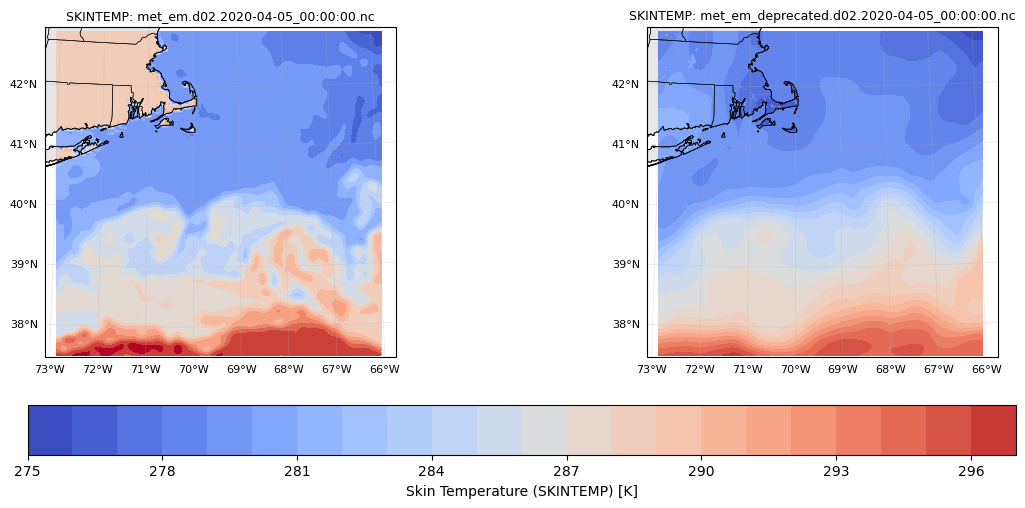

In [34]:

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5),
    subplot_kw={"projection": proj_map},
    constrained_layout=True
)

for i, (ax, skin, title) in enumerate(zip(axes, [skin1, skin2], titles)):
    ax.set_extent(bounds, crs=proj_data)   # bounds are lon/lat -> PlateCarree

    ax.add_feature(cfeature.LAND, facecolor="0.9")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.STATES, linewidth=0.4)

    gl = ax.gridlines(
        crs=proj_data,          # use PlateCarree for lon/lat gridlines
        draw_labels=True,
        linewidth=0.4,
        alpha=0.5,
        linestyle="--"
    )

    gl.bottom_labels = True
    gl.left_labels   = True
    gl.top_labels    = False
    gl.right_labels  = False

    gl.x_inline = False
    gl.y_inline = False
    gl.rotate_labels = False

    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

    cf = ax.contourf(
        lon, lat, skin,
        levels=20,
        cmap="coolwarm",
        vmin=vmin, vmax=vmax,
        transform=proj_data                 # IMPORTANT
    )
    ax.set_title(title, fontsize=9)

# ------------------------------------------------------------
# 5. Shared colorbar
# ------------------------------------------------------------
cbar = fig.colorbar(cf, ax=axes, orientation="horizontal", pad=0.08)
cbar.set_label("Skin Temperature (SKINTEMP) [K]")

# ------------------------------------------------------------
# 6. Save figure
# ------------------------------------------------------------
save = "SKINTEMP_side_by_side.png"
fig.savefig(save, dpi=200)
print(f"[OK] Saved figure → {save}")

plt.show()
